In [3]:
# %pip install matplotlib

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# 一般作法

In [5]:
def calculate_return(signal):
    # signal = [日期, 評分, 價格]
    hold = 0  # 持有的股數
    balance = 10000000
    init_balance = balance

    list_rtn = []

    for idx, item in enumerate(signal):
        if idx == len(signal) - 1:
            break
        score = float(item[1])
        price = float(signal[idx+1][2])

        # if hold == 0:
        #     if score > 0:
        #         hold += int(balance/price)
        #         balance = 0
        # elif hold > 0:
        #     if score < 0:
        #         balance += price*hold
        #         hold = 0

        if hold == 0:
            if score == 2:
                hold += int(balance/price)
                balance = 0
            elif score == 1:
                hold += int((balance/2)/price)
                balance = int(balance/2)
        elif hold > 0:
            if score < 0:
                balance += price*hold
                hold = 0
            elif score == 2:
                hold += int(balance/price)
                balance = 0
        # print(f"score: {score}, price: {price}, hold: {hold}, balance: {balance}, total: {balance + hold*price}")

        list_rtn.append((balance + hold*price)/init_balance)
    
    balance += hold*price
    last_price = float(signal[len(signal) - 1][2])
    r = balance/init_balance

    # plt.title({stock_id})
    # plt.plot(list_rtn, label=f'strategy', color='red')
    # plt.plot(list_bnh, label='buy and hold', color='blue')
    # plt.legend()
    # plt.show()

    return round(r, 5)

157 策略失敗0.9283140000000001
158 策略失敗0.936244
159 策略失敗1.112743
160 策略失敗0.952314
161 策略失敗1.063195
162 策略失敗1.0547309999999999
163 策略失敗1.056491
164 策略失敗0.996738
165 策略失敗1.109253
166 策略失敗1.1466260000000001
167 策略失敗0.9761960000000002
168 策略失敗0.973208
169 策略失敗0.9778940000000003
170 策略失敗1.099262
171 策略失敗1.090652
172 策略失敗1.102273
173 策略失敗1.1003669999999999
174 策略失敗1.0616189999999999
175 策略失敗1.0384410000000002
176 策略失敗1.015718
177 策略失敗0.9925519999999999
178 策略失敗1.0065600000000001
179 策略失敗0.9874239999999999
180 策略失敗1.0234100000000002
181 策略失敗1.0410220000000001
182 策略失敗1.035455
183 策略失敗1.047423
184 策略失敗1.11752
185 策略失敗1.0426549999999999
186 策略勝利
187 策略失敗1.015859
188 策略失敗1.037226
189 策略失敗1.143562
190 策略失敗1.001739
191 策略失敗1.028615
192 策略失敗0.9850409999999998
193 策略失敗1.0136299999999998
194 策略失敗1.0222069999999999
195 策略失敗1.091141
196 策略失敗0.9657490000000001
197 策略失敗1.0982230000000002
198 策略失敗1.058025
199 策略失敗1.0271599999999999
200 策略失敗1.023603
201 策略失敗1.0756330000000003
202 策略失敗1.0849929999999999
203 策略失

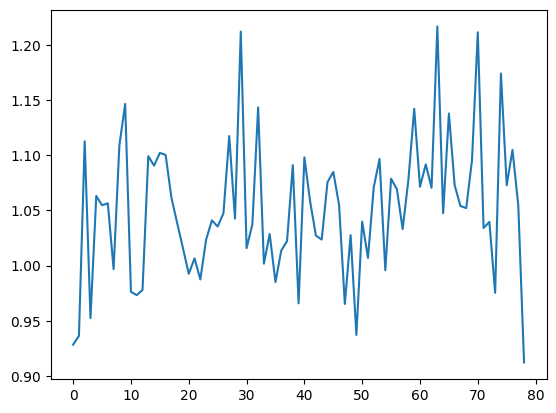

In [6]:
# 88 ~ 137 -100~100
# 157 ~ 235 #非常好(2) #好(1) #無關(0) #不好(-1) #非常不好(-2)

# 20220101 ~ 20231231 兩年的10擋股票報酬率 1.186132
# 20230101 ~ 20231231 一年的10擋股票報酬率 1.170022

import matplotlib.pyplot as plt
import ast
list_2 = []

for i in range(157, 236):
    rtns = []
    bnhs = []
    eval_list = []

    with open("eval_gemini/output"+str(i), "r", encoding='utf-8') as f:
        data = f.read()
        eval_list = ast.literal_eval(data.split("原始數據")[1])

    for list in eval_list:
        rtn = calculate_return(list)
        # print(f'報酬率:{rtn}，總額投入報酬率:{bnh} ',end="==>")  
        # print("勝利" if rtn > bnh else "失敗")
        rtns.append(rtn)

    # print("_"*50)
    # print(f'平均報酬率:{sum(rtns) / len(rtns)}，平均總額投入報酬率:{1.186132}')
    print(str(i) + " 策略勝利" if sum(rtns) / len(rtns) > 1.186132 else str(i) + " 策略失敗" + str(sum(rtns) / len(rtns)))
    list_2.append(sum(rtns) / len(rtns))

plt.plot(list_2)
print(list_2)

# 另一種計算方法

In [72]:
def calculate_return_2(signal, price):
    increase = 0
    decrease = 0
    for idx, item in enumerate(signal):
        index_location = price.index.get_loc(int(item[0]))  # 獲取特定索引的位置
        if index_location == len(price.index) - 1:
            break
        next_index = price.index[index_location + 1]  # 獲取下一個索引的位置
        next_row = price.loc[next_index]  # 找到下一個索引的行
        # print(next_row)
        if item[1] == '2':
            if next_row['Close'] > next_row['Open']:
                # print('漲')
                increase += 1
            else:
                # print('跌或沒動')
                decrease += 1
        if item[1] == '1':
            if next_row['Close'] > next_row['Open']:
                # print('漲')
                increase += 1
            else:
                # print('跌或沒動')
                decrease += 1
    
    return increase, decrease

In [73]:
import ast

stock_ids = ["1101", "2211", "2385", "2542", "2880", "2912", "3023", "3264", "5269", "8027"]
with open("eval_gemini/output234", "r", encoding='utf-8') as f:
    data = f.read()
    eval_list = ast.literal_eval(data.split("原始數據")[1])

for i, list in enumerate(eval_list):
    dataframe = pd.read_csv(os.path.dirname(os.path.abspath(os.getcwd())) + "/price_history/" + stock_ids[i] + "price.csv", usecols=['Date', 'Open', 'Close'])
    dataframe.set_index('Date', inplace=True)  # 將'Date'行設置為索引
    print(calculate_return_2(list, dataframe))
    
    

(30, 40)
(5, 3)
(19, 14)
(10, 6)
(17, 20)
(42, 52)
(27, 27)
(4, 7)
(19, 16)
(7, 8)


In [54]:
import pandas as pd

# 建立一個簡單的DataFrame
data = {
    'Date': ['20220101', '20220102', '20220103', '20220104'],
    'Open': [100, 101, 102, 103],
    'Close': [105, 106, 107, 108]
}
df = pd.DataFrame(data)

# 將'Date'列設置為索引
df.set_index('Date', inplace=True)

# 透過索引值取得該行的內容
target_date = '20220103'
next_row = None
for index, row in df.iterrows():
    if next_row is not None:
        print(next_row)
        break
    if index == target_date:
        next_row = row

print(next_row)

Open     102
Close    107
Name: 20220103, dtype: int64
Open     102
Close    107
Name: 20220103, dtype: int64
